<div style="background-color: #1A3A5C; padding: 30px; border-radius: 10px; text-align: center;">
  <h1 style="color: white; font-size: 2em; margin-bottom: 8px;">
     Laboratório — Quantização e Codificação PCM
  </h1>
  <h2 style="color: #AED6F1; font-weight: normal; margin-bottom: 6px;">
    Quantização Uniforme · SQNR · Companding µ-Law · PCM
  </h2>
  <h3 style="color: #AED6F1; font-weight: normal; margin-bottom: 4px;">
    Disciplina: Processamento Digital de Sinais
  </h3>
  <h3 style="color: #AED6F1; font-weight: normal;">
    Professora: Luciana Ribeiro Veloso — UFCG / DEE
  </h3>
</div>

---

## Sobre este laboratório

Este notebook cobre a **segunda etapa da conversão analógico-digital**: a quantização da amplitude
e a codificação em palavras binárias (PCM). Junto com a amostragem (laboratório anterior),
forma o pipeline ADC completo.

| Seção | Conteúdo |
|---|---|
| **1** | Motivação perceptiva — ouça os efeitos antes de formalizar |
| **2** | Quantização uniforme — mid-tread, mid-rise, passo $\Delta$, níveis $L = 2^B$ |
| **3** | Erro de quantização — distribuição, potência, visualização |
| **4** | SQNR — teoria + verificação experimental com simulador |
| **5** | Experimento visual com imagem — aliasing de amplitude |
| **6** | Quantização não-uniforme — companding e µ-Law (G.711) |
| **7** | PCM — pipeline ADC completo: amostragem → quantização → codificação |
| **8** | Experimento com voz ao vivo — $B = 1, 2, 4, 8, 16$ bits + µ-Law |
| **9** | Roteiro de sala |
| **10** | Questões |

---

> **Pré-requisito:** Teorema de Nyquist e amostragem (laboratório anterior).
> O pipeline ADC completo fecha-se aqui com a quantização e a codificação PCM.


---

##  Configuração — execute esta célula antes de qualquer experimento

Importa todas as bibliotecas e define a paleta de cores padrão do laboratório.
**Execute uma única vez ao abrir o notebook.**


In [1]:
# ── Bibliotecas científicas ───────────────────────────────────────
import numpy as np
from scipy.signal import spectrogram
from scipy.io import wavfile
from skimage import data

# ── Visualização ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

# ── Áudio e interatividade ────────────────────────────────────────
from IPython.display import Audio, display, HTML
import sounddevice as sd
import IPython.display as ipd
import ipywidgets as widgets

# ── Estilo visual padrão ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.color'       : '#dee2e6',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
})

# ── Paleta de cores padrão do laboratório ─────────────────────────
C_ORIG  = '#1A5FA8'   # azul   — sinal original
C_QUANT = '#C0392B'   # verm.  — sinal quantizado
C_ERRO  = '#117A65'   # verde  — erro de quantização
C_MULAW = '#8E44AD'   # roxo   — µ-Law
C_TEORIA= '#E67E22'   # laran. — curva teórica
C_CINZA = '#5D6D7E'   # cinza  — referência

print('Configuração concluída — pode executar as seções a seguir.')


Configuração concluída — pode executar as seções a seguir.


---

## <span style="color: #1A5FA8;">1. Motivação Perceptiva — Ouça Antes de Formalizar</span>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 14px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #1A5FA8;">Por que começar pelo ouvido?</strong><br>
A quantização é a etapa que determina a <em>qualidade sonora</em> de um sinal digital.
Antes de qualquer equação, ouça o efeito de reduzir progressivamente o número de bits —
quando a fórmula $\text{SQNR} \approx 6{,}02B + 1{,}76$ dB aparecer, ela
já terá significado concreto.
</div>

| Bits $B$ | Níveis $L = 2^B$ | SQNR teórico | O que esperar |
|:---:|:---:|:---:|---|
| 1 | 2 | 7,8 dB | Apenas sinal ou silêncio — irreconhecível |
| 2 | 4 | 13,8 dB | Forma muito distorcida |
| 4 | 16 | 25,8 dB | Reconhecível, muito ruidoso |
| 8 | 256 | 49,9 dB | Qualidade telefônica |
| 16 | 65.536 | 98,1 dB | Qualidade CD — fiel ao original |




### Etapa 1 — Carregar o sinal de audio

In [2]:
from scipy.io import wavfile

caminho = "/Users/lucianaveloso/Library/CloudStorage/GoogleDrive-luciana.veloso@dee.ufcg.edu.br/Meu Drive/UFCG/Disciplinas/PDS/2026/Labs/handel.wav"

try:
    SAMP_RATE, dados = wavfile.read(caminho)
    if len(dados.shape) > 1:
        dados = dados[:, 0]
    sinal_orig = dados.astype(float) / np.max(np.abs(dados))

except FileNotFoundError:
    print("Arquivo não encontrado — usando sinal sintético.")
    SAMP_RATE  = 8000
    t          = np.linspace(0, 3, SAMP_RATE * 3)
    sinal_orig = np.sin(2 * np.pi * 440 * t)

sinal_orig /= np.max(np.abs(sinal_orig))   # normaliza uma única vez

bits = [1, 2, 4, 8, 16]
FS   = SAMP_RATE

dur_real = len(sinal_orig) / SAMP_RATE
print(f'Sinal: {len(sinal_orig):,} amostras  |  Fs = {SAMP_RATE} Hz  |  {dur_real:.1f} s')
print(f'Bits a comparar: {bits}')


Sinal: 73,113 amostras  |  Fs = 8192 Hz  |  8.9 s
Bits a comparar: [1, 2, 4, 8, 16]


### Etapa 2 — Quantizar e reproduzir

In [3]:
def quantizar_uniforme(x, B, A=1.0):
    '''
    Quantizador mid-tread uniforme com B bits.

    Fórmula: xq(n) = Delta * floor(x(n)/Delta + 1/2)
    com Delta = 2*A / 2^B

    Níveis de representação: -(L/2)*Delta, ..., -Delta, 0, Delta, ..., (L/2-1)*Delta
    Total: L = 2^B níveis.

    Nota: para L par, o mid-tread é ligeiramente assimétrico — o nível mais
    negativo -(L/2)*Delta tem região de decisão 1.5x mais larga que os demais.
    Isso é comportamento padrão na literatura (Oppenheim & Schafer, Proakis)
    e implica diferença de ~1-3 dB no SQNR medido vs. teórico para B pequeno.
    Para B >= 8 (uso prático) a diferença é < 1 dB.
    '''
    L     = 2 ** B
    delta = 2.0 * A / L
    xq    = delta * np.floor(x / delta + 0.5)
    # Clip aplicado no RESULTADO para garantir L = 2^B níveis válidos
    xq    = np.clip(xq, -(L // 2) * delta, (L // 2 - 1) * delta)
    return xq

print('Pipeline: sinal  →  quantizador(B bits)  →  Audio')
print('=' * 60)

for B in bits:
    x_q  = quantizar_uniforme(sinal_orig, B)
    L    = 2 ** B
    sqnr = 6.02 * B + 1.76

    display(HTML(
        f'<b>B = {B} bits &nbsp;|&nbsp; L = {L:,} níveis &nbsp;|&nbsp; '
        f'SQNR teórico = {sqnr:.1f} dB</b>'
    ))
    display(Audio(x_q, rate=FS))

print('=' * 60)
print('A partir de quantos bits o sinal fica reconhecível?')


Pipeline: sinal  →  quantizador(B bits)  →  Audio


A partir de quantos bits o sinal fica reconhecível?


###  O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Escuta comparativa</strong><br>
Com 1 e 2 bits, o sinal é quase irreconhecível — há apenas 2 ou 4 níveis de amplitude.
Com 8 bits (padrão telefônico), a qualidade já é aceitável. Com 16 bits (padrão CD), o
sinal é perceptualmente idêntico ao original. Cada bit adicional melhora a qualidade
de forma consistente, a SQNR descreve isso.
</div>

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #E67E22;">Para registrar</strong><br>
Qual o menor $B$ em que o sinal ficou reconhecível?
Compare com o SQNR teórico correspondente na tabela acima.
</div>


---

## <span style="color: #1A5FA8;">2. Quantização Uniforme</span>

### Definição

A **quantização uniforme** mapeia cada amostra contínua $x(n) \in [-A, A]$
para o nível de representação mais próximo de um conjunto finito de $L = 2^B$ valores
igualmente espaçados.

$$\boxed{\Delta = \frac{2A}{L} = \frac{2A}{2^B}}$$

As fórmulas de quantização para os dois tipos são:

$$\text{Mid-tread:}\quad x_q(n) = \Delta\left\lfloor\frac{x(n)}{\Delta}+\frac{1}{2}\right\rfloor$$

$$\text{Mid-rise:}\quad x_q(n) = \Delta\left(\left\lfloor\frac{x(n)}{\Delta}\right\rfloor+\frac{1}{2}\right)$$

### Mid-tread vs. Mid-rise

Os dois tipos de quantizador uniforme diferem na posição dos níveis em relação à origem:

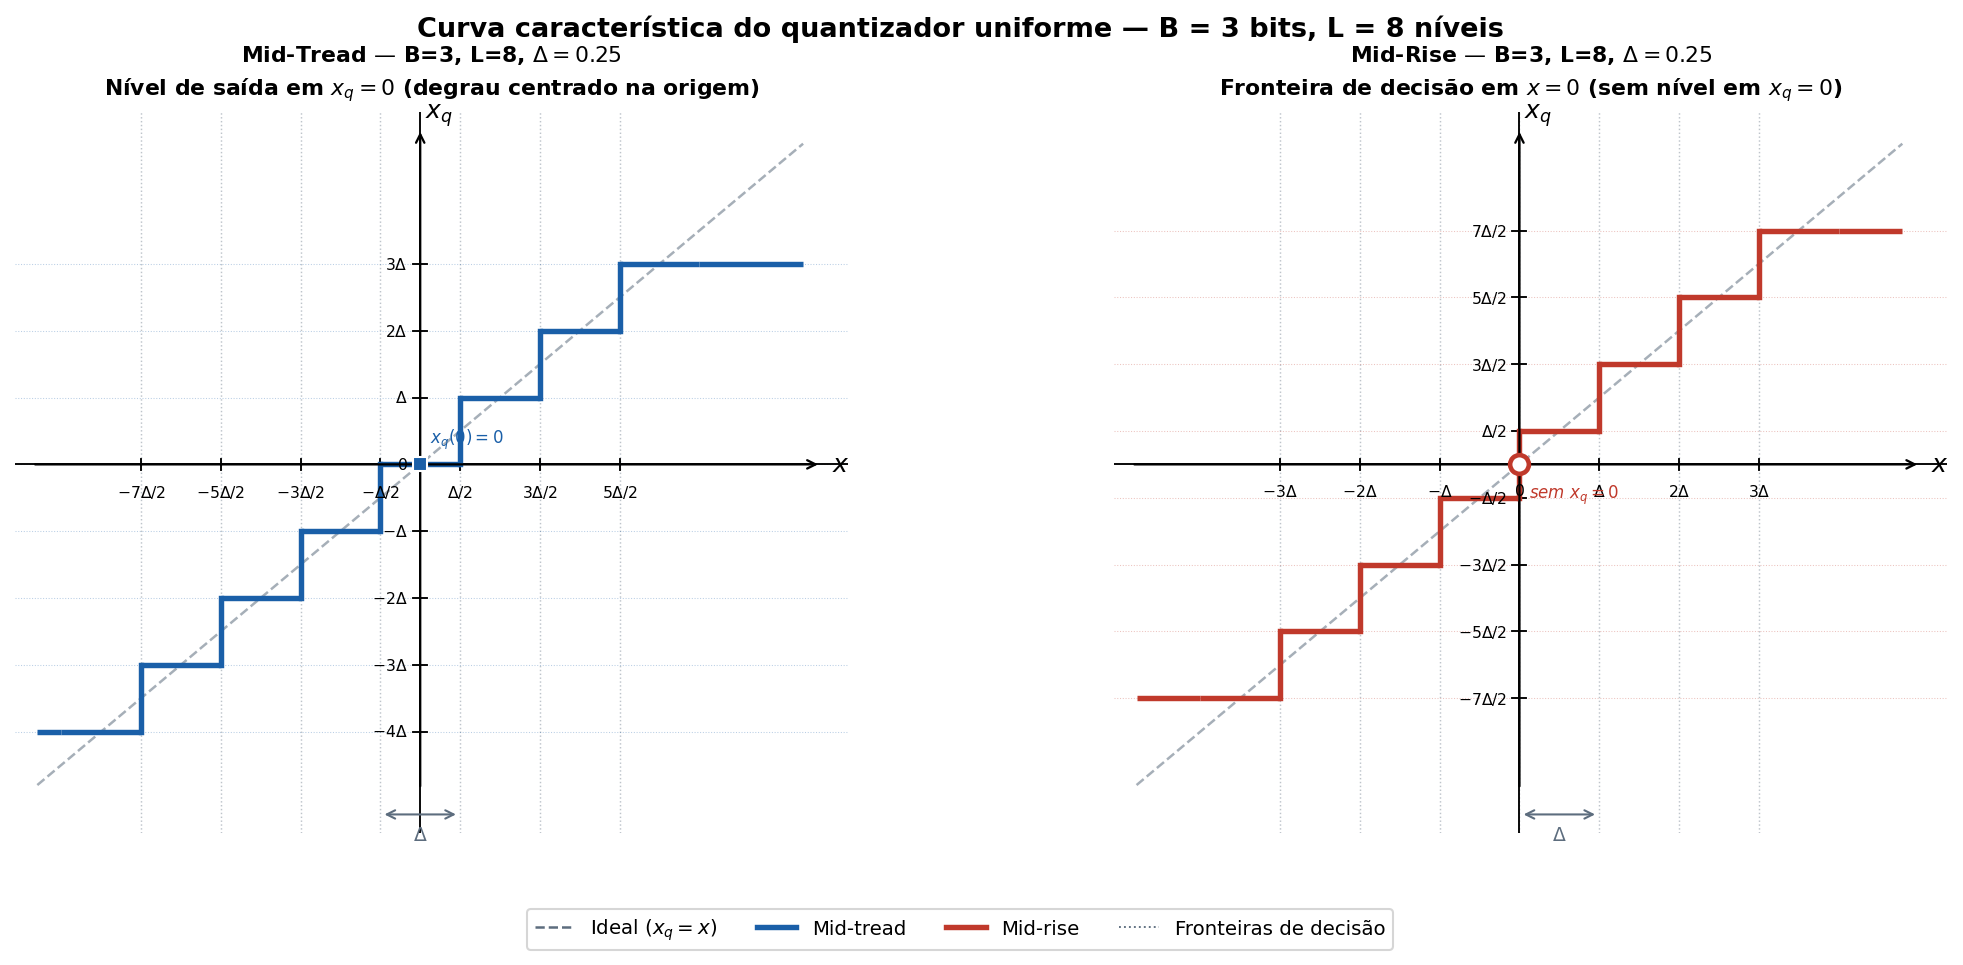

| Característica | Mid-tread | Mid-rise |
|---|---|---|
| Nível em $x = 0$ | Sim ($x_q = 0$) | Não |
| Número de níveis | $2^B$ (clip assimétrico) | $2^B$ (simétrico) |
| Uso típico | Voz (G.711) | Áudio geral |

### Parâmetros fundamentais

| Símbolo | Significado | Fórmula |
|---|---|---|
| $B$ | Número de bits por amostra | dado |
| $L$ | Número de níveis de quantização | $L = 2^B$ |
| $\Delta$ | Passo (step size) | $\Delta = 2A / 2^B$ |
| $A$ | Valor máximo do sinal | dado |



### Etapa 1 — Parâmetros do experimento

In [4]:
Fs_exp  = 400        # Hz
F0      = 5         # Hz
dur_exp = 1.0       # s
A       = 1.0

t_exp  = np.linspace(0, dur_exp, int(Fs_exp * dur_exp), endpoint=False)
x_ref  = A * np.sin(2 * np.pi * F0 * t_exp)

bits_exp = [1, 2, 3, 4, 8]

print(f'Sinal de referência: sen({F0} Hz) @ Fs = {Fs_exp} Hz')
print(f'Amplitude A = {A}  |  Bits: {bits_exp}')
print()
print(f'{"B":>4} | {"L=2^B":>7} | {"Δ=2A/L":>8} | {"SQNR teórico":>14}')
print('-' * 42)
for B in bits_exp:
    L     = 2 ** B
    delta = 2 * A / L
    sqnr  = 6.02 * B + 1.76
    print(f'{B:>4} | {L:>7,} | {delta:>8.4f} | {sqnr:>13.2f} dB')


Sinal de referência: sen(5 Hz) @ Fs = 400 Hz
Amplitude A = 1.0  |  Bits: [1, 2, 3, 4, 8]

   B |   L=2^B |   Δ=2A/L |   SQNR teórico
------------------------------------------
   1 |       2 |   1.0000 |          7.78 dB
   2 |       4 |   0.5000 |         13.80 dB
   3 |       8 |   0.2500 |         19.82 dB
   4 |      16 |   0.1250 |         25.84 dB
   8 |     256 |   0.0078 |         49.92 dB


### Etapa 2 — Visualizar curva característica (mid-tread vs. mid-rise)

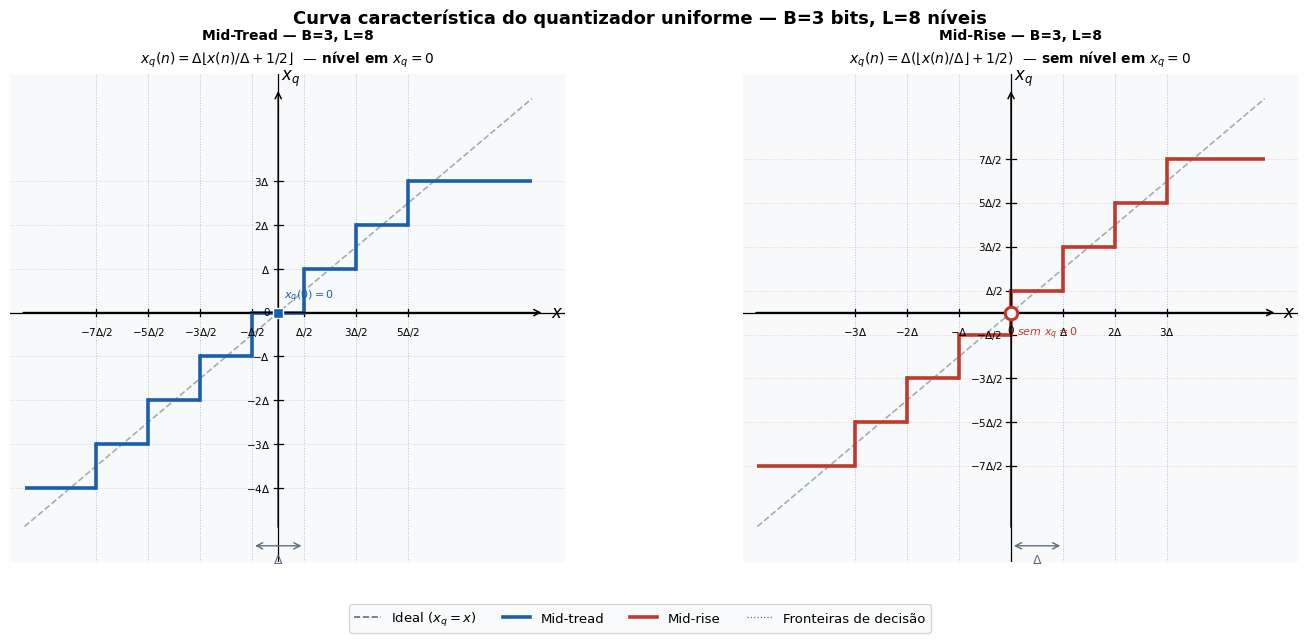

Mid-tread: 8 níveis | inclui zero: True
Mid-rise:  8 níveis | inclui zero: False


In [5]:
B_demo = 3   # 8 niveis — bom para visualizar a escada
L      = 2 ** B_demo
Delta  = 2 * A / L

x_cont = np.linspace(-A - 0.02, A + 0.02, 8000)

# ── Implementações corretas ───────────────────────────────────────
def midtread(x, B=3, A=1.0):
    '''
    xq(n) = Delta * floor(x(n)/Delta + 1/2)
    Nível de saída em xq = 0. Clip assimétrico padrão da literatura.
    '''
    L = 2**B; d = 2*A/L
    xq = d * np.floor(x/d + 0.5)
    xq = np.clip(xq, -(L//2)*d, (L//2 - 1)*d)
    return xq

def midrise(x, B=3, A=1.0):
    '''
    xq(n) = Delta * (floor(x(n)/Delta) + 1/2)
    Fronteira de decisão em x = 0. Sem nível em xq = 0.
    '''
    L = 2**B; d = 2*A/L
    xq = d * (np.floor(x/d) + 0.5)
    xq = np.clip(xq, -A + d/2, A - d/2)
    return xq

xq_mt = midtread(x_cont, B_demo, A)
xq_mr = midrise (x_cont, B_demo, A)

nmt = sorted(set(np.round(xq_mt, 8)))
nmr = sorted(set(np.round(xq_mr, 8)))

def fronteiras_de(niveis, delta):
    n = niveis
    return ([n[0] - delta/2] +
            [(n[i]+n[i+1])/2 for i in range(len(n)-1)] +
            [n[-1] + delta/2])

fmt = fronteiras_de(nmt, Delta)
fmr = fronteiras_de(nmr, Delta)

def lbl(v, d):
    k = round(v/d, 6)
    if k == 0: return '0'
    ki = int(round(k*2))
    if ki % 2 == 0:
        n = ki//2
        if n ==  1: return r'$\Delta$'
        if n == -1: return r'$-\Delta$'
        return fr'${n}\Delta$'
    else:
        if ki ==  1: return r'$\Delta/2$'
        if ki == -1: return r'$-\Delta/2$'
        return fr'${ki}\Delta/2$'

def draw(ax, niveis, fronteiras, cor, titulo, tem_zero):
    pad = 0.22
    xl0, xr0 = -A - pad, A + pad
    ax.plot([xl0, xr0], [xl0, xr0], '--',
            color=C_CINZA, lw=1.2, alpha=0.55, zorder=1)
    for i, nv in enumerate(niveis):
        xl = fronteiras[i]; xr = fronteiras[i+1]
        ax.plot([xl, xr], [nv, nv], color=cor, lw=2.6,
                solid_capstyle='butt', zorder=3)
        if i < len(niveis)-1:
            ax.plot([xr, xr], [nv, niveis[i+1]], color=cor, lw=2.6, zorder=3)
    ax.plot([xl0, fronteiras[0]],  [niveis[0],  niveis[0]],
            color=cor, lw=2.6, solid_capstyle='butt', zorder=3)
    ax.plot([fronteiras[-1], xr0], [niveis[-1], niveis[-1]],
            color=cor, lw=2.6, solid_capstyle='butt', zorder=3)
    for fb in fronteiras[1:-1]:
        ax.axvline(fb, color=C_CINZA, lw=0.7, ls=':', alpha=0.40, zorder=1)
    for nv in niveis:
        ax.axhline(nv, color=cor, lw=0.5, ls=':', alpha=0.30, zorder=1)
    ax.axhline(0, color='black', lw=0.9, zorder=2)
    ax.axvline(0, color='black', lw=0.9, zorder=2)
    kw = dict(arrowstyle='->', color='black', lw=1.1)
    ax.annotate('', xy=(xr0+0.06, 0), xytext=(xl0-0.02, 0), arrowprops=kw)
    ax.annotate('', xy=(0, xr0+0.06), xytext=(0, xl0-0.02), arrowprops=kw)
    ax.text(xr0+0.09, 0,       '$x$',   ha='left',  va='center', fontsize=12)
    ax.text(0.015,    xr0+0.06,'$x_q$', ha='left',  va='bottom', fontsize=12)
    for fb in fronteiras[1:-1]:
        ax.plot([fb,fb], [-0.022, 0.022], 'k-', lw=0.9)
        ax.text(fb, -0.07, lbl(fb, Delta), ha='center', va='top', fontsize=7.5)
    for nv in niveis:
        ax.plot([-0.022, 0.022], [nv,nv], 'k-', lw=0.9)
        ax.text(-0.04, nv, lbl(nv, Delta), ha='right', va='center', fontsize=7.5)
    if tem_zero:
        ax.plot(0, 0, 's', color=cor, ms=7,
                markeredgecolor='white', markeredgewidth=1.0, zorder=6)
        ax.text(0.03, 0.05, r'$x_q(0)=0$',
                ha='left', va='bottom', fontsize=8, color=cor, style='italic')
    else:
        ax.plot(0, 0, 'o', color='white', ms=9,
                markeredgecolor=cor, markeredgewidth=2.2, zorder=6)
        ax.text(0.03, -0.07, r'sem $x_q=0$',
                ha='left', va='top', fontsize=8, color=cor, style='italic')
    fb0 = fronteiras[len(niveis)//2]; fb1 = fronteiras[len(niveis)//2+1]
    y_ann = xl0 - 0.11
    ax.annotate('', xy=(fb1, y_ann), xytext=(fb0, y_ann),
                arrowprops=dict(arrowstyle='<->', color=C_CINZA, lw=1.0))
    ax.text((fb0+fb1)/2, y_ann-0.04, r'$\Delta$',
            ha='center', va='top', fontsize=9, color=C_CINZA)
    ax.set_title(titulo, fontsize=10, fontweight='bold', pad=8, linespacing=1.5)
    ax.set_xlim([xl0-0.07, xr0+0.16])
    ax.set_ylim([xl0-0.20, xr0+0.14])
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), facecolor='white')
plt.subplots_adjust(wspace=0.32, top=0.87, bottom=0.12,
                    left=0.05, right=0.97)

draw(axes[0], nmt, fmt, C_ORIG,
     f'Mid-Tread — B={B_demo}, L={L}\n'
     r'$x_q(n)=\Delta\lfloor x(n)/\Delta+1/2\rfloor$'
     '  — nível em $x_q=0$',
     tem_zero=True)

draw(axes[1], nmr, fmr, C_QUANT,
     f'Mid-Rise — B={B_demo}, L={L}\n'
     r'$x_q(n)=\Delta(\lfloor x(n)/\Delta\rfloor+1/2)$'
     '  — sem nível em $x_q=0$',
     tem_zero=False)

fig.suptitle(
    f'Curva característica do quantizador uniforme — B={B_demo} bits, L={L} níveis',
    fontsize=13, fontweight='bold', y=0.97)

handles = [
    Line2D([0],[0], ls='--', color=C_CINZA, lw=1.2, label='Ideal ($x_q=x$)'),
    Line2D([0],[0], color=C_ORIG,  lw=2.6, label='Mid-tread'),
    Line2D([0],[0], color=C_QUANT, lw=2.6, label='Mid-rise'),
    Line2D([0],[0], ls=':', color=C_CINZA, lw=0.9, label='Fronteiras de decisão'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=9.5, bbox_to_anchor=(0.5, 0.00), frameon=True)
plt.show()

print(f'Mid-tread: {len(nmt)} níveis | inclui zero: {0.0 in nmt}')
print(f'Mid-rise:  {len(nmr)} níveis | inclui zero: {0.0 in nmr}')


### Etapa 3 — Comparar formas de onda para diferentes B

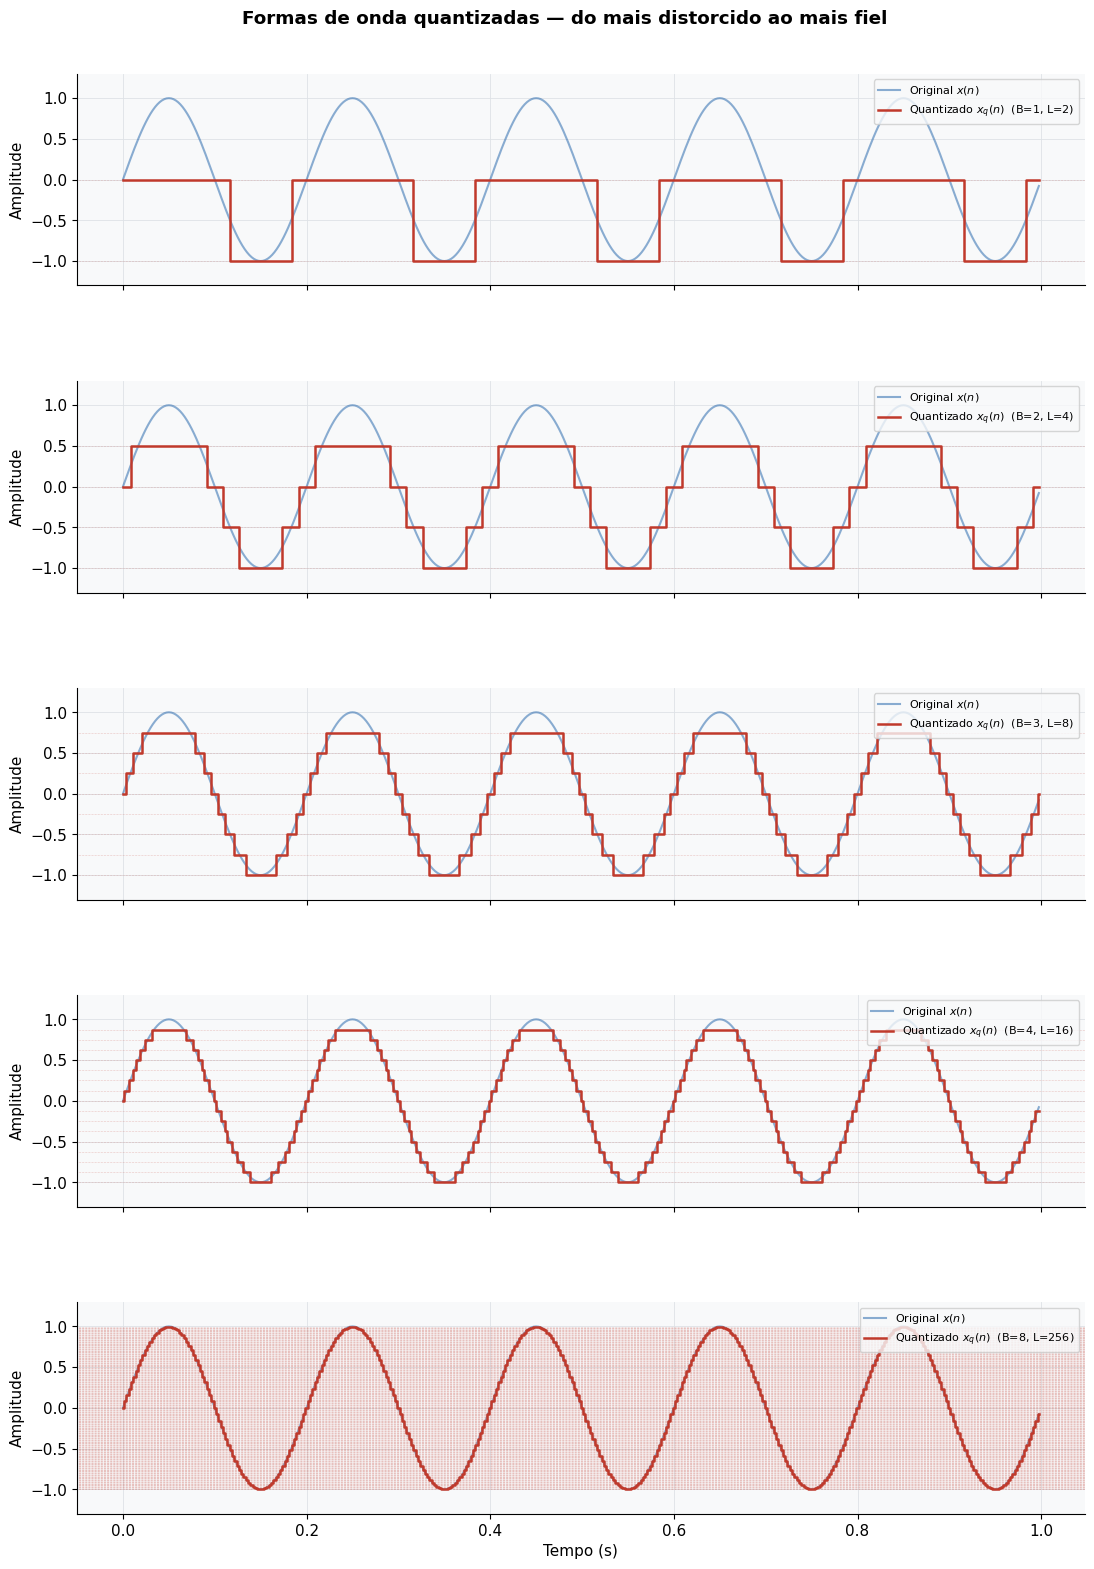

In [6]:
fig, axes = plt.subplots(len(bits_exp), 1, figsize=(13, 3.2 * len(bits_exp)),
                         sharex=True)
plt.subplots_adjust(hspace=0.45, top=0.95, bottom=0.05)

for ax, B in zip(axes, bits_exp):
    x_q   = quantizar_uniforme(x_ref, B, A)
    L     = 2 ** B
    delta = 2 * A / L

    ax.plot(t_exp, x_ref, color=C_ORIG,  lw=1.5, alpha=0.5, label='Original $x(n)$')
    ax.step(t_exp, x_q,   color=C_QUANT, lw=1.8, where='mid',
            label=f'Quantizado $x_q(n)$  (B={B}, L={L})')
    ax.set_ylabel('Amplitude'); ax.set_ylim([-1.3, 1.3])
    ax.legend(fontsize=8, loc='upper right')

    # Linhas nos níveis de saída do mid-tread: -(L/2)*D, ..., 0, ..., (L/2-1)*D
    for k in range(-(L//2), L//2):
        ax.axhline(k * delta, color=C_QUANT, lw=0.4, ls=':', alpha=0.5)

axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Formas de onda quantizadas — do mais distorcido ao mais fiel',
             fontweight='bold', y=0.99)
plt.show()


### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Curvas características</strong><br>
A curva mid-tread tem um degrau plano centrado em $x = 0$ — por isso o nível zero
é representado exatamente. No mid-rise, a fronteira de decisão passa pelo zero,
e o menor valor representável é $\pm \Delta/2$.
</div>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #1A5FA8;">Formas de onda</strong><br>
Para B=1 e B=2, a "escada" é visível a olho nu. Para B=8 a senoide quantizada
é visualmente indistinguível da original — mas o erro ainda existe e pode ser
medido numericamente.
</div>


---

## <span style="color: #1A5FA8;">3. Erro de Quantização</span>

### Definição

O **erro de quantização** é a diferença entre o sinal quantizado e o original:

$$\boxed{e(n) = x_q(n) - x(n)}$$

Para um quantizador uniforme ideal (sem sobrecarga), o erro é modelado como uma
variável aleatória com **distribuição uniforme** em $[-\Delta/2,\; \Delta/2]$:

$$e(n) \sim \mathcal{U}\!\left[-\frac{\Delta}{2},\, \frac{\Delta}{2}\right]$$

### Potência do erro (ruído de quantização)

$$\sigma_e^2 = \mathbb{E}[e^2(n)] = \frac{\Delta^2}{12} = \frac{A^2}{3 \cdot 2^{2B}}$$

A potência do ruído **cai por um fator 4 a cada bit adicional, equivalente a,
$6{,}02$ dB por bit.

### Quando o modelo falha

O modelo uniforme do erro vale quando $B \geq 4$ e o sinal ocupa bem a faixa do
quantizador. Para poucos bits ou sinais com distribuição muito concentrada,
o erro exibe estrutura periódica (granularidade) e o modelo não se aplica.


### Etapa 1 — Calcular e visualizar o erro para vários B

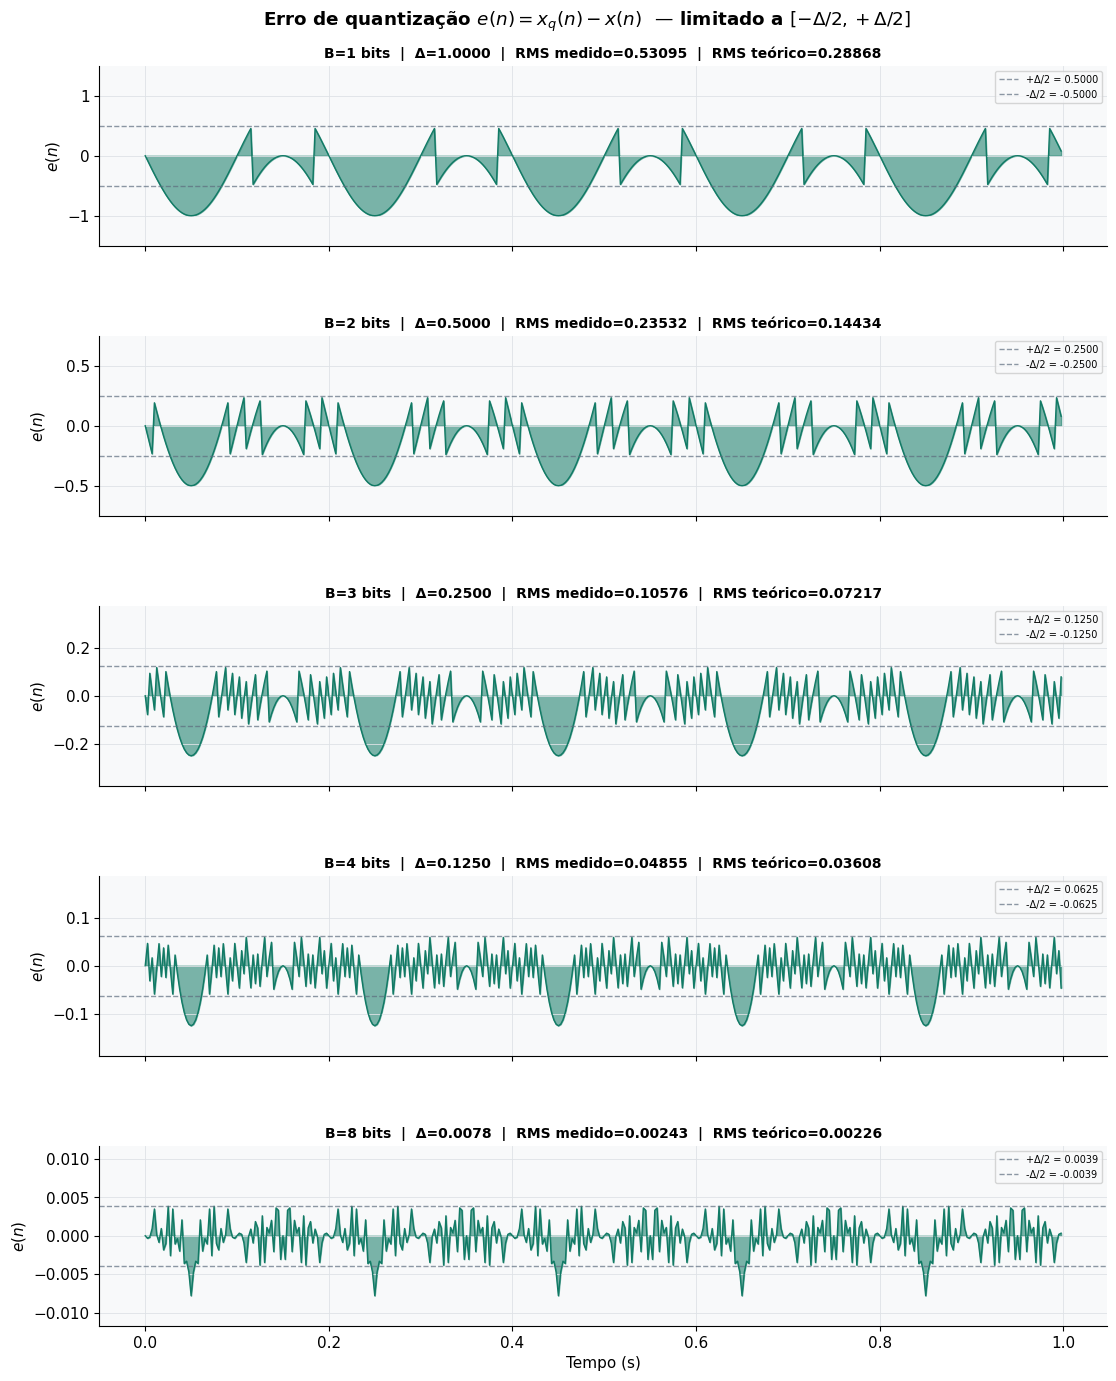

In [7]:
fig, axes = plt.subplots(len(bits_exp), 1, figsize=(13, 2.8 * len(bits_exp)),
                         sharex=True)
plt.subplots_adjust(hspace=0.50, top=0.95, bottom=0.05)

for ax, B in zip(axes, bits_exp):
    x_q   = quantizar_uniforme(x_ref, B)
    erro  = x_q - x_ref
    delta = 2 * A / (2 ** B)
    rms   = np.sqrt(np.mean(erro ** 2))

    ax.fill_between(t_exp, erro, color=C_ERRO, alpha=0.55)
    ax.plot(t_exp, erro, color=C_ERRO, lw=1.0)
    ax.axhline( delta/2, color=C_CINZA, lw=1, ls='--', alpha=0.7, label=f'+Δ/2 = {delta/2:.4f}')
    ax.axhline(-delta/2, color=C_CINZA, lw=1, ls='--', alpha=0.7, label=f'-Δ/2 = {-delta/2:.4f}')
    ax.set_ylabel('$e(n)$')
    ax.set_ylim([-delta * 1.5, delta * 1.5])
    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(f'B={B} bits  |  Δ={delta:.4f}  |  RMS medido={rms:.5f}  |  '
                 f'RMS teórico={delta / (2*np.sqrt(3)):.5f}', fontsize=10)

axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Erro de quantização $e(n) = x_q(n) - x(n)$  — limitado a $[-\Delta/2, +\Delta/2]$',
             fontweight='bold', y=0.99)
plt.show()


### Etapa 2 — Distribuição do erro (histograma)

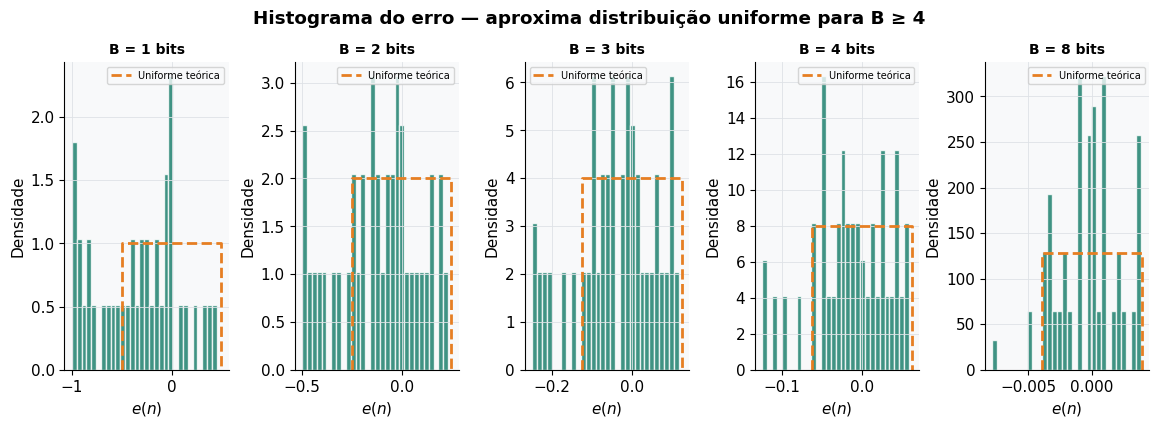

Obs: para B=1 e B=2, o histograma mostra picos discretos (granularidade).
O modelo uniforme do erro é uma aproximação que melhora com mais bits.


In [8]:
fig, axes = plt.subplots(1, len(bits_exp), figsize=(14, 4))
plt.subplots_adjust(wspace=0.40, top=0.88)

for ax, B in zip(axes, bits_exp):
    x_q   = quantizar_uniforme(x_ref, B)
    erro  = x_q - x_ref
    delta = 2 * A / (2 ** B)

    ax.hist(erro, bins=30, color=C_ERRO, edgecolor='white',
            density=True, alpha=0.8)
    # Distribuicao uniforme teorica
    xe = np.array([-delta/2, -delta/2, delta/2, delta/2])
    ye = np.array([0, 1/delta, 1/delta, 0])
    ax.plot(xe, ye, color=C_TEORIA, lw=2, ls='--', label='Uniforme teórica')

    ax.set_title(f'B = {B} bits', fontsize=10)
    ax.set_xlabel('$e(n)$'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=7)

fig.suptitle('Histograma do erro — aproxima distribuição uniforme para B ≥ 4',
             fontweight='bold', y=1.01)
plt.show()

print('Obs: para B=1 e B=2, o histograma mostra picos discretos (granularidade).')
print('O modelo uniforme do erro é uma aproximação que melhora com mais bits.')


### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Erro limitado pelo passo Δ</strong><br>
O erro está sempre confinado entre $-\Delta/2$ e $+\Delta/2$ (linhas tracejadas).
Conforme $B$ aumenta, $\Delta$ diminui e o erro fica cada vez menor.
</div>

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #E67E22;">RMS medido vs. teórico</strong><br>
Para B ≥ 4, o RMS medido converge para $\Delta/(2\sqrt{3})$ — a previsão teórica da
distribuição uniforme. Para B pequeno, o erro tem estrutura periódica (granularidade)
e o modelo é uma aproximação ruim.
</div>


---

## <span style="color: #1A5FA8;">4. SQNR — Razão Sinal-Ruído de Quantização</span>

### Definição e fórmula

$$\boxed{\text{SQNR} = \frac{\sigma_x^2}{\sigma_e^2}}$$

Para uma senoide de amplitude $A$ (potência $\sigma_x^2 = A^2/2$) e quantizador uniforme
com $B$ bits (potência do erro $\sigma_e^2 = \Delta^2/12 = A^2/(3 \cdot 2^{2B})$):

$$\text{SQNR}_{\text{senoide}} = \frac{A^2/2}{A^2/(3 \cdot 2^{2B})} = \frac{3}{2}\cdot 2^{2B}$$

Em dB:

$$\boxed{\text{SQNR}_{\text{dB}} = 10\log_{10}\!\left(\frac{3}{2}\right) + 20B\log_{10}(2) \approx 1{,}76 + 6{,}02\,B \text{ dB}}$$

### Regra dos 6 dB

**Cada bit adicional melhora o SQNR em aproximadamente 6 dB.**

| B | L | SQNR (dB) | Aplicação |
|:---:|:---:|:---:|---|
| 4 | 16 | 25,8 | Voz de baixa qualidade |
| 8 | 256 | 49,9 | Telefonia (G.711 PCM) |
| 16 | 65.536 | 98,1 | CD de áudio |
| 24 | 16.777.216 | 146,2 | Áudio profissional |


### Etapa 1 — Calcular SQNR experimental para diferentes B

In [9]:
# ── Calcular SQNR teorico e medido para varios B ──────────────────
Bs     = np.arange(1, 17)
sqnr_teo  = 6.02 * Bs + 1.76
sqnr_med  = []

for B in Bs:
    x_q  = quantizar_uniforme(x_ref, B)
    erro = x_q - x_ref
    pot_sinal = np.mean(x_ref ** 2)
    pot_erro  = np.mean(erro  ** 2)
    sqnr_med.append(10 * np.log10(pot_sinal / (pot_erro + 1e-30)))

sqnr_med = np.array(sqnr_med)

print(f'{"B":>4} | {"SQNR teórico (dB)":>19} | {"SQNR medido (dB)":>18} | {"Diferença":>10}')
print('-' * 58)
for B, st, sm in zip(Bs, sqnr_teo, sqnr_med):
    print(f'{B:>4} | {st:>19.2f} | {sm:>18.2f} | {sm-st:>+9.2f}')


   B |   SQNR teórico (dB) |   SQNR medido (dB) |  Diferença
----------------------------------------------------------
   1 |                7.78 |               2.49 |     -5.29
   2 |               13.80 |               9.56 |     -4.24
   3 |               19.82 |              16.50 |     -3.32
   4 |               25.84 |              23.27 |     -2.57
   5 |               31.86 |              29.88 |     -1.98
   6 |               37.88 |              35.61 |     -2.27
   7 |               43.90 |              43.19 |     -0.71
   8 |               49.92 |              49.29 |     -0.63
   9 |               55.94 |              56.50 |     +0.56
  10 |               61.96 |              61.35 |     -0.61
  11 |               67.98 |              68.76 |     +0.78
  12 |               74.00 |              75.05 |     +1.05
  13 |               80.02 |              78.26 |     -1.76
  14 |               86.04 |              85.30 |     -0.74
  15 |               92.06 |            

### Etapa 2 — Gráfico SQNR × número de bits

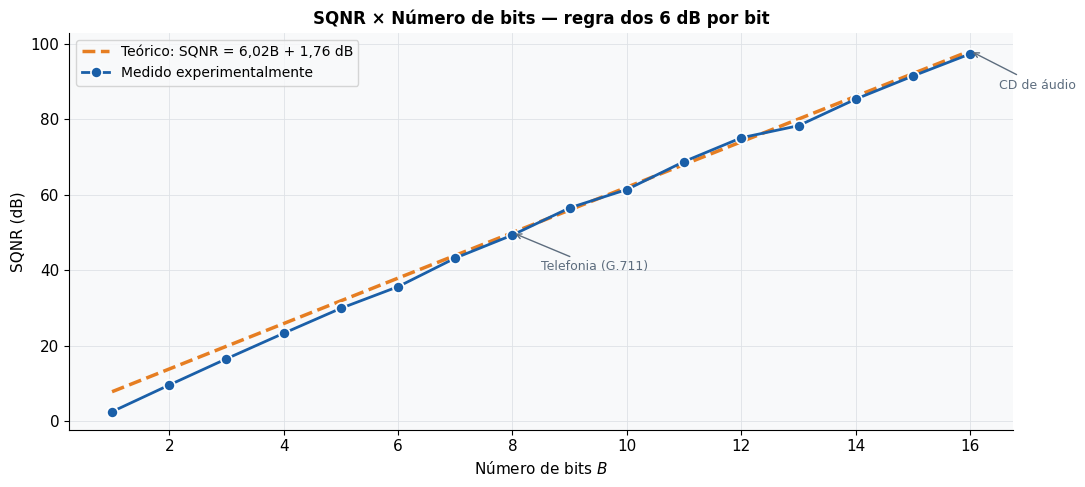

Inclinação medida: 6.32 dB/bit
Previsto pela teoria: 6.02 dB/bit


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(Bs, sqnr_teo, '--', color=C_TEORIA, lw=2.5,
        label=f'Teórico: SQNR = 6,02B + 1,76 dB')
ax.plot(Bs, sqnr_med, 'o-', color=C_ORIG, lw=2, ms=8,
        markeredgecolor='white', markeredgewidth=1.2,
        label='Medido experimentalmente')

# Marcar aplicacoes
marcas = {8: 'Telefonia (G.711)', 16: 'CD de áudio'}
for B, label in marcas.items():
    idx = B - 1
    ax.annotate(label,
                xy=(B, sqnr_teo[idx]),
                xytext=(B + 0.5, sqnr_teo[idx] - 10),
                fontsize=9, color=C_CINZA,
                arrowprops=dict(arrowstyle='->', color=C_CINZA, lw=1))

ax.set_xlabel('Número de bits $B$')
ax.set_ylabel('SQNR (dB)')
ax.set_title('SQNR × Número de bits — regra dos 6 dB por bit', fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(f'Inclinação medida: {(sqnr_med[-1] - sqnr_med[0]) / (Bs[-1] - Bs[0]):.2f} dB/bit')
print(f'Previsto pela teoria: 6.02 dB/bit')


### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Linearidade em dB</strong><br>
O gráfico é quase perfeitamente linear — cada bit adiciona ≈ 6 dB ao SQNR.
A pequena divergência para B=1 e B=2 ocorre porque o modelo do erro uniforme
não é válido para poucos bits.
</div>




---

## <span style="color: #1A5FA8;">5. Experimento Visual — Quantização de Imagem</span>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 14px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #1A5FA8;">Por que usar uma imagem?</strong><br>
Uma imagem em escala de cinza é um sinal 2D $x(m, n) \in [0, 255]$.
Reduzir o número de bits de quantização é equivalente a reduzir o número de
tons de cinza disponíveis — o efeito é imediatamente visível como
<strong>aliasing de amplitude</strong> (falsos contornos / posterização).
</div>

### Conexão com a teoria

| Sinais de áudio | Imagens |
|---|---|
| Amplitude $x(n) \in [-A, A]$ | Nível de cinza $x(m,n) \in [0, 255]$ |
| Níveis $L = 2^B$ | Tons de cinza $L = 2^B$ |
| Ruído de quantização audível | Posterização (falsos contornos) visível |
| SQNR em dB | PSNR (Peak SNR) em dB |


### Etapa 1 — Carregar imagem e definir função de quantização

In [11]:
# ── Imagem original (512×512, 8 bits = 256 tons de cinza) ─────────
img_orig = data.camera().astype(float)   # [0, 255]
H, W     = img_orig.shape
print(f'Imagem: {W}×{H} pixels  |  Original: 8 bits (256 tons)')

def quantizar_imagem(img, B):
    '''Quantiza imagem para B bits (L = 2^B tons de cinza).'''
    L       = 2 ** B
    delta   = 256.0 / L
    img_q   = np.floor(img / delta) * delta + delta / 2
    return np.clip(img_q, 0, 255)

bits_img = [1, 2, 3, 4, 6, 8]
print(f'Bits a comparar: {bits_img}')


Imagem: 512×512 pixels  |  Original: 8 bits (256 tons)
Bits a comparar: [1, 2, 3, 4, 6, 8]


### Etapa 2 — Visualizar imagens com diferentes resoluções de amplitude

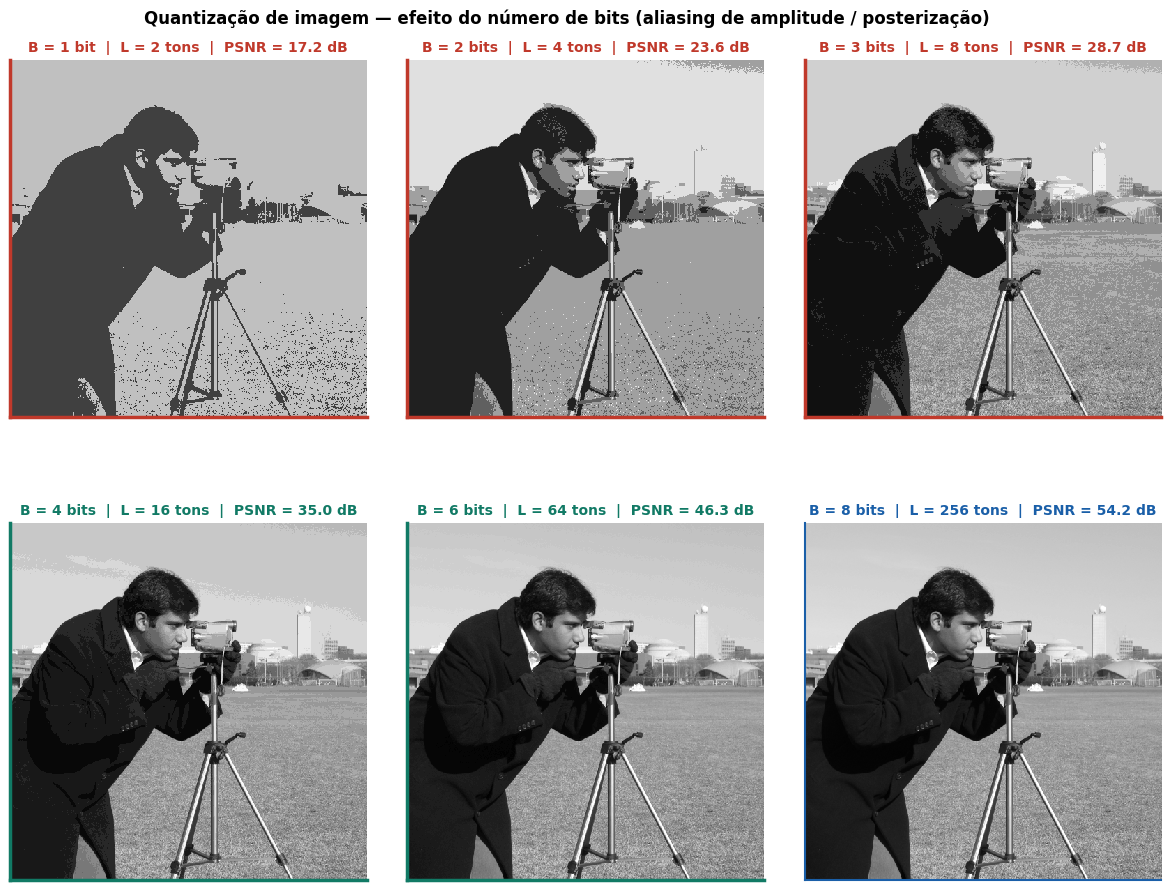

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor='white')
plt.subplots_adjust(hspace=0.30, wspace=0.08, top=0.93)

def estilizar(ax, cor, lw=2.5):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color(cor); s.set_linewidth(lw)

for ax, B in zip(axes.flat, bits_img):
    img_q  = quantizar_imagem(img_orig, B)
    L      = 2 ** B
    delta  = 256.0 / L
    erro   = img_q - img_orig
    psnr   = 10 * np.log10(255**2 / (np.mean(erro**2) + 1e-30))

    ax.imshow(img_q, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    cor = C_ORIG if B == 8 else (C_ERRO if B >= 4 else C_QUANT)
    ax.set_title(f'B = {B} bit{"s" if B>1 else ""}  |  L = {L} tons  |  PSNR = {psnr:.1f} dB',
                 fontsize=10, fontweight='bold', color=cor, pad=6)
    estilizar(ax, cor, lw=1.5 if B == 8 else 2.5)

fig.suptitle('Quantização de imagem — efeito do número de bits (aliasing de amplitude / posterização)',
             fontsize=12, fontweight='bold')
plt.show()


### Etapa 3 — Erro de quantização na imagem e PSNR

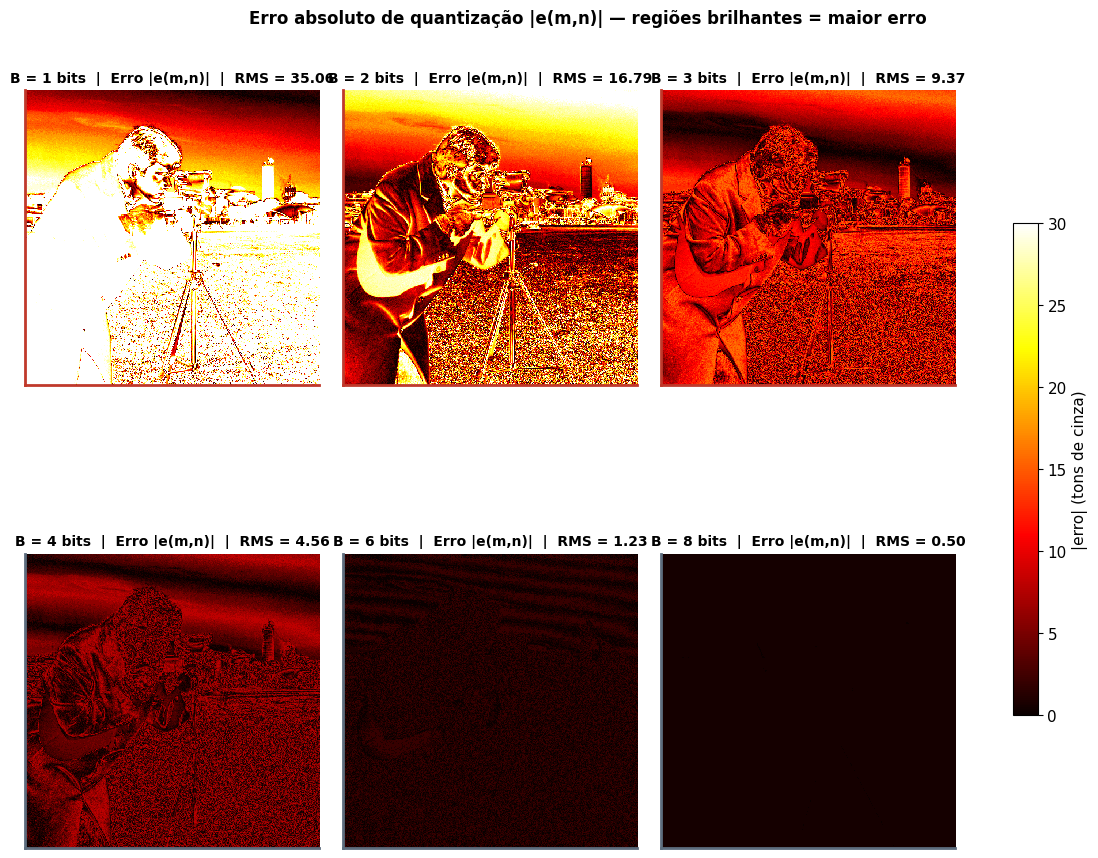

   B |        L |   RMS erro |   PSNR (dB) |  SQNR teórico
--------------------------------------------------------
   1 |        2 |     35.060 |       17.23 |         7.78 dB
   2 |        4 |     16.794 |       23.63 |        13.80 dB
   3 |        8 |      9.365 |       28.70 |        19.82 dB
   4 |       16 |      4.557 |       34.96 |        25.84 dB
   6 |       64 |      1.230 |       46.33 |        37.88 dB
   8 |      256 |      0.500 |       54.16 |        49.92 dB


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor='white')
plt.subplots_adjust(hspace=0.30, wspace=0.08, top=0.93)

def estilizar(ax, cor, lw=2.0):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color(cor); s.set_linewidth(lw)

for ax, B in zip(axes.flat, bits_img):
    img_q = quantizar_imagem(img_orig, B)
    erro  = np.abs(img_q - img_orig)  # erro absoluto

    pcm = ax.imshow(erro, cmap='hot', vmin=0, vmax=30, interpolation='nearest')
    L   = 2 ** B
    rms = np.sqrt(np.mean((img_q - img_orig)**2))
    ax.set_title(f'B = {B} bits  |  Erro |e(m,n)|  |  RMS = {rms:.2f}',
                 fontsize=10, fontweight='bold', pad=6)
    estilizar(ax, C_QUANT if B < 4 else C_CINZA)

plt.colorbar(pcm, ax=axes, shrink=0.6, label='|erro| (tons de cinza)')
fig.suptitle('Erro absoluto de quantização |e(m,n)| — regiões brilhantes = maior erro',
             fontsize=12, fontweight='bold')
plt.show()

# PSNR vs bits
print(f'{"B":>4} | {"L":>8} | {"RMS erro":>10} | {"PSNR (dB)":>11} | {"SQNR teórico":>13}')
print('-' * 56)
for B in bits_img:
    img_q = quantizar_imagem(img_orig, B)
    erro  = img_q - img_orig
    rms   = np.sqrt(np.mean(erro**2))
    psnr  = 10 * np.log10(255**2 / (rms**2 + 1e-30))
    sqnr  = 6.02 * B + 1.76
    print(f'{B:>4} | {2**B:>8,} | {rms:>10.3f} | {psnr:>11.2f} | {sqnr:>12.2f} dB')


### 💡 O que observar

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #A32D2D;">B=1 e B=2 — posterização severa</strong><br>
Com apenas 2 ou 4 tons, a imagem perde toda a gradação tonal — regiões de transição
suave aparecem como <strong>falsas bordas abruptas</strong> (posterização).
Esse é o aliasing de amplitude: o quantizador "inventa" contornos que não existem.
</div>

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">B=6 — início da fidelidade</strong><br>
Com 64 tons, a imagem já é razoavelmente fiel ao original. B=8 (padrão de imagens)
torna os falsos contornos imperceptíveis ao olho humano — o limiar perceptual
para imagens está próximo de 6 bits.
</div>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #1A5FA8;">Mapa de erro</strong><br>
As regiões mais brilhantes no mapa de erro correspondem às bordas e gradientes
da imagem original — exatamente onde a quantização introduz mais distorção,
pois é onde a amplitude varia mais entre pixels vizinhos.
</div>


---

## <span style="color: #1A5FA8;">6. Quantização Não-Uniforme — Companding e µ-Law</span>

### O problema da quantização uniforme para voz

Para sinais de voz, a distribuição de amplitude é fortemente concentrada em
valores pequenos — a voz é silenciosa ou de baixa amplitude na maior parte do tempo.
Com um quantizador uniforme, os sinais fracos têm poucos níveis disponíveis e
o SQNR cai drasticamente para amplitudes baixas.

### Solução: companding (compressão + expansão)

```
Codificador:  x(n)  →  [compressor f(x)]  →  [quantizador uniforme]  →  código
Decodificador: código →  [dequantizador]   →  [expansor f⁻¹(y)]      →  x_q(n)
```

### µ-Law (G.711 — padrão norte-americano)

$$\boxed{y = F(x) = \text{sgn}(x) \cdot \frac{\ln(1 + \mu|x|)}{\ln(1 + \mu)}, \qquad \mu = 255}$$

**Propriedade:** o SQNR permanece aproximadamente constante para uma faixa
dinâmica de 40 dB de amplitude — ao contrário do quantizador uniforme, cujo
SQNR cai 6 dB para cada metade da amplitude.

| Característica | Quantização uniforme | µ-Law (8 bits) |
|---|---|---|
| Níveis | $2^B$ igualmente espaçados | Mais níveis para sinais fracos |
| SQNR para sinal forte | Alto | Alto |
| SQNR para sinal fraco | Baixo (degrada) | Constante (~38 dB) |
| Uso | Áudio de alta qualidade | Telefonia (G.711) |
| Bits | 16 (CD) | **8 bits** |


### Etapa 1 — Implementar compressor e expansor µ-Law

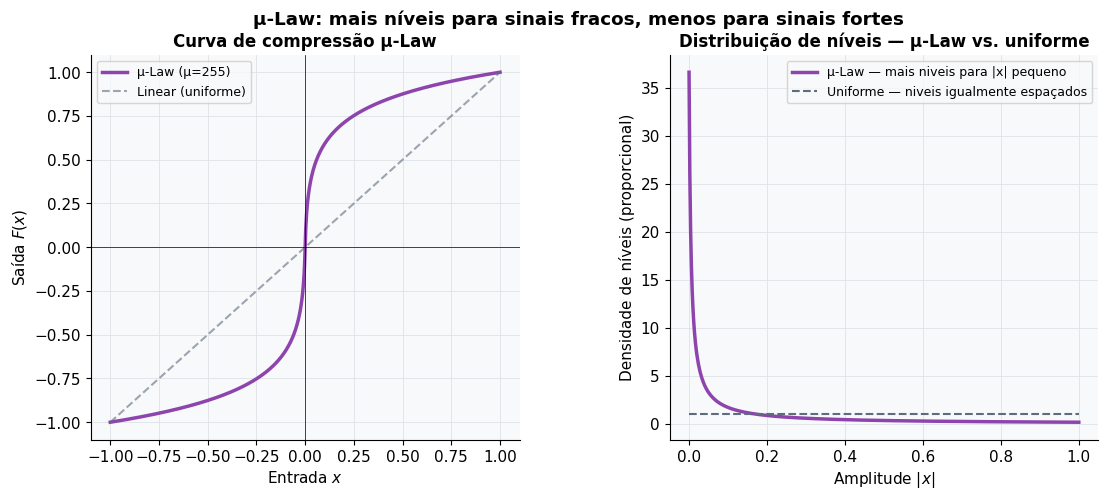

In [14]:
MU = 255   # parametro padrao G.711

def compressor_mu(x, mu=MU):
    '''Funcao de compressao mu-law: F(x) = sgn(x) * ln(1 + mu|x|) / ln(1+mu)'''
    return np.sign(x) * np.log1p(mu * np.abs(x)) / np.log1p(mu)

def expansor_mu(y, mu=MU):
    '''Funcao inversa (expansao): F^-1(y)'''
    return np.sign(y) * (1/mu) * ((1 + mu) ** np.abs(y) - 1)

# ── Visualizar curva de compressao ────────────────────────────────
x_vis = np.linspace(-1, 1, 1000)
y_vis = compressor_mu(x_vis)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.subplots_adjust(wspace=0.35, top=0.88)

# Curva de compressao
ax = axes[0]
ax.plot(x_vis, y_vis,    color=C_MULAW, lw=2.5, label='µ-Law (µ=255)')
ax.plot(x_vis, x_vis,    '--', color=C_CINZA, lw=1.5, label='Linear (uniforme)', alpha=0.6)
ax.set_xlabel('Entrada $x$'); ax.set_ylabel('Saída $F(x)$')
ax.set_title('Curva de compressão µ-Law')
ax.legend(fontsize=9)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)

# Densidade de niveis (derivada da curva de compressao)
ax = axes[1]
x_pos = np.linspace(0.001, 1, 500)
densidade_mu  = MU / ((1 + MU * x_pos) * np.log1p(MU))
densidade_lin = np.ones_like(x_pos)

ax.plot(x_pos, densidade_mu,  color=C_MULAW, lw=2.5, label='µ-Law — mais niveis para |x| pequeno')
ax.plot(x_pos, densidade_lin, '--', color=C_CINZA, lw=1.5, label='Uniforme — niveis igualmente espaçados')
ax.set_xlabel('Amplitude $|x|$'); ax.set_ylabel('Densidade de níveis (proporcional)')
ax.set_title('Distribuição de níveis — µ-Law vs. uniforme')
ax.legend(fontsize=9)

fig.suptitle('µ-Law: mais níveis para sinais fracos, menos para sinais fortes',
             fontweight='bold', y=0.97)
plt.show()


### Etapa 2 — Comparar SQNR uniforme vs. µ-Law em função da amplitude

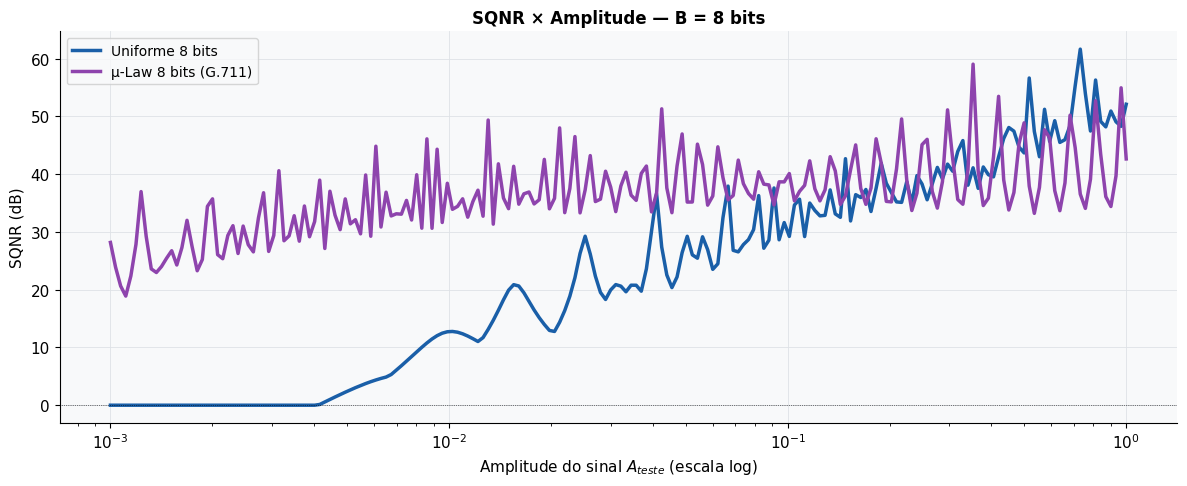

Observe: o SQNR do quantizador uniforme cai ~6 dB a cada vez que a
amplitude cai pela metade. O µ-Law mantém o SQNR aproximadamente constante.


In [15]:
amplitudes = np.logspace(-3, 0, 200)   # de 0.001 a 1.0
B_comp     = 8                          # mesmo numero de bits

sqnr_unif  = []
sqnr_mulaw = []

for A_test in amplitudes:
    # Sinal senoidal com amplitude A_test
    x_test = A_test * np.sin(2 * np.pi * 440 * t_exp)

    # Quantizacao uniforme
    x_q_u  = quantizar_uniforme(x_test / A, B_comp) * A
    e_u    = x_q_u - x_test
    sqnr_u = 10 * np.log10(np.mean(x_test**2) / (np.mean(e_u**2) + 1e-30))
    sqnr_unif.append(sqnr_u)

    # Quantizacao mu-law
    x_norm  = x_test / A                    # normaliza para [-1, 1]
    y_comp  = compressor_mu(x_norm)          # comprime
    y_q     = quantizar_uniforme(y_comp, B_comp)  # quantiza
    x_rec   = expansor_mu(y_q) * A          # expande e desnormaliza
    e_mu    = x_rec - x_test
    sqnr_mu = 10 * np.log10(np.mean(x_test**2) / (np.mean(e_mu**2) + 1e-30))
    sqnr_mulaw.append(sqnr_mu)

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogx(amplitudes, sqnr_unif,  color=C_ORIG,  lw=2.5, label=f'Uniforme {B_comp} bits')
ax.semilogx(amplitudes, sqnr_mulaw, color=C_MULAW, lw=2.5, label=f'µ-Law {B_comp} bits (G.711)')

ax.set_xlabel('Amplitude do sinal $A_{teste}$ (escala log)')
ax.set_ylabel('SQNR (dB)')
ax.set_title(f'SQNR × Amplitude — B = {B_comp} bits', fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='black', lw=0.5, ls=':')
plt.tight_layout()
plt.show()

print('Observe: o SQNR do quantizador uniforme cai ~6 dB a cada vez que a')
print('amplitude cai pela metade. O µ-Law mantém o SQNR aproximadamente constante.')


### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Curva de compressão</strong><br>
A função µ-Law comprime os sinais fortes (muita variação → pouca variação)
e preserva os sinais fracos (pouca variação → mantém). Isso distribui
mais níveis de quantização para as amplitudes pequenas — exatamente onde a voz
passa mais tempo.
</div>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #1A5FA8;">SQNR × Amplitude</strong><br>
Com o quantizador uniforme, o SQNR cai linearmente (em dB) conforme a amplitude
diminui — sinais fracos são mal representados. Com o µ-Law, o SQNR permanece
aproximadamente constante sobre uma faixa dinâmica de 40 dB. Por isso o G.711
usa apenas 8 bits e mantém qualidade telefônica aceitável.
</div>


---

## <span style="color: #1A5FA8;">7. PCM — Pulse Code Modulation</span>

### Pipeline ADC completo

O PCM é o resultado da combinação das três etapas da conversão analógico-digital:

```
x_c(t) ──► [Filtro AA] ──► [Amostrador ↓Fs] ──► [Quantizador B bits] ──► [Codificador] ──► bits
              LPF                 Nyquist            Mid-tread/µ-Law        binário natural
              ω_c=π/Ts            x(n)=x_c(nT)       x_q(n)                 código PCM
```

### Codificação binária

Cada nível de quantização é mapeado para uma **palavra binária de $B$ bits**.
Para um quantizador com $L = 2^B$ níveis:

$$\text{índice}(n) = \left\lfloor \frac{x(n) - x_{min}}{\Delta} \right\rfloor, \quad \text{código}(n) = \text{bin}(\text{índice}(n),\, B\text{ bits})$$

### Taxa de bits (bit rate)

$$\boxed{R_{bits} = B \times F_s \times N_{\text{canais}} \text{ bits/s}}$$

| Aplicação | $F_s$ | $B$ | $R_{bits}$ |
|---|---|---|---|
| Telefonia G.711 | 8.000 Hz | 8 bits | 64 kbps |
| CD de áudio (estéreo) | 44.100 Hz | 16 bits | 1.411 kbps (× 2 canais) |
| Áudio profissional | 96.000 Hz | 24 bits | 2.304 kbps |


### Etapa 1 — Simular o pipeline PCM completo

In [16]:
# ── Pipeline PCM: amostragem + quantizacao + codificacao ──────────
Fs_pcm  = 8000    # Hz — G.711
B_pcm   = 8       # bits
dur_pcm = 0.01    # s — janela curta para visualizar os bits

t_pcm   = np.linspace(0, dur_pcm, int(Fs_pcm * dur_pcm), endpoint=False)
x_pcm   = np.sin(2 * np.pi * 440 * t_pcm)   # senoide 440 Hz

# Quantizacao
x_q_pcm = quantizar_uniforme(x_pcm, B_pcm)

# Codificacao: mapear nivel -> indice -> palavra binaria
# Consistente com mid-tread: nivel k*delta -> indice k + L//2
# Ex: nivel 0 -> indice 128 (centro), nivel -(L/2)*delta -> indice 0
L_pcm   = 2 ** B_pcm
delta_p = 2.0 / L_pcm
indices = np.round(x_q_pcm / delta_p).astype(int) + L_pcm // 2
indices = np.clip(indices, 0, L_pcm - 1)

# Gerar palavras binarias
palavras = [format(idx, f'0{B_pcm}b') for idx in indices]

# Bitstream completo
bitstream = ''.join(palavras)

print('=== PIPELINE PCM ===')
print(f'Sinal: senoide 440 Hz  |  Fs = {Fs_pcm} Hz  |  B = {B_pcm} bits')
print(f'Numero de amostras na janela: {len(t_pcm)}')
print(f'Taxa de bits: {B_pcm * Fs_pcm:,} bps = {B_pcm * Fs_pcm / 1000:.0f} kbps')
print()
print(f'{"Amostra n":>10} | {"x(n)":>8} | {"x_q(n)":>8} | {"índice":>7} | {"código PCM"}')
print('-' * 55)
for n in range(min(8, len(t_pcm))):
    print(f'{n:>10} | {x_pcm[n]:>8.4f} | {x_q_pcm[n]:>8.4f} | {indices[n]:>7} | {palavras[n]}')
print(f'  ...  ({len(t_pcm)} amostras no total)')
print()
print(f'Primeiros 64 bits do bitstream PCM:')
print(bitstream[:64])


=== PIPELINE PCM ===
Sinal: senoide 440 Hz  |  Fs = 8000 Hz  |  B = 8 bits
Numero de amostras na janela: 80
Taxa de bits: 64,000 bps = 64 kbps

 Amostra n |     x(n) |   x_q(n) |  índice | código PCM
-------------------------------------------------------
         0 |   0.0000 |   0.0000 |     128 | 10000000
         1 |   0.3387 |   0.3359 |     171 | 10101011
         2 |   0.6374 |   0.6406 |     210 | 11010010
         3 |   0.8607 |   0.8594 |     238 | 11101110
         4 |   0.9823 |   0.9844 |     254 | 11111110
         5 |   0.9877 |   0.9844 |     254 | 11111110
         6 |   0.8763 |   0.8750 |     240 | 11110000
         7 |   0.6613 |   0.6641 |     213 | 11010101
  ...  (80 amostras no total)

Primeiros 64 bits do bitstream PCM:
1000000010101011110100101110111011111110111111101111000011010101


### Etapa 2 — Visualizar o sinal quantizado e o bitstream

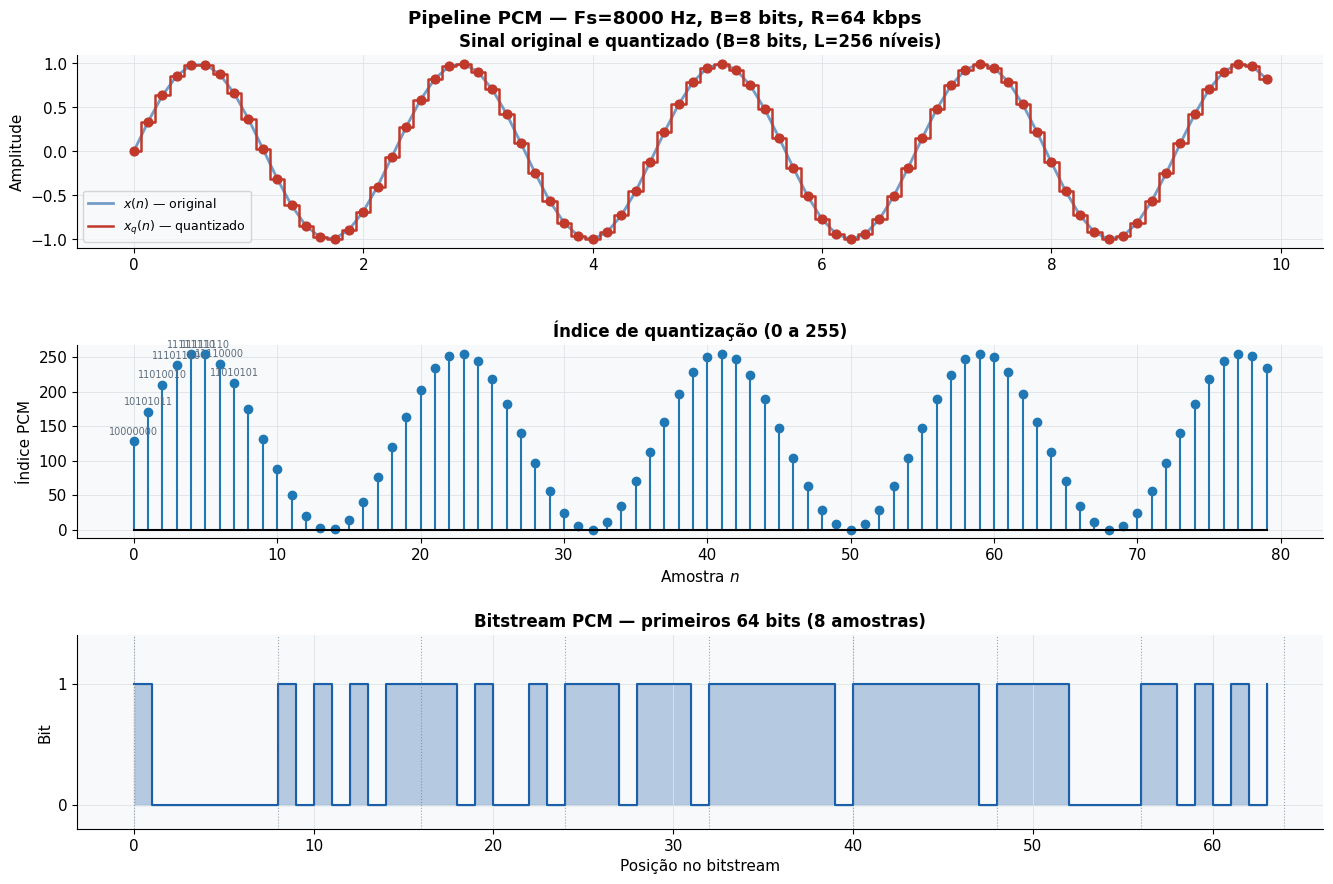

In [17]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.50,
                        top=0.92, bottom=0.06, left=0.08, right=0.97)

# ── Sinal original + quantizado ───────────────────────────────────
ax1 = fig.add_subplot(gs[0])
t_ms = t_pcm * 1000
ax1.plot(t_ms, x_pcm,   color=C_ORIG,  lw=2,   alpha=0.6, label='$x(n)$ — original')
ax1.step(t_ms, x_q_pcm, color=C_QUANT, lw=1.8, where='mid', label='$x_q(n)$ — quantizado')
ax1.scatter(t_ms, x_q_pcm, color=C_QUANT, s=40, zorder=5)
ax1.set_ylabel('Amplitude'); ax1.legend(fontsize=9)
ax1.set_title(f'Sinal original e quantizado (B={B_pcm} bits, L={L_pcm} níveis)')

# ── Índices e palavras binárias ───────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.stem(range(len(indices)), indices,
         linefmt=f'C0-', markerfmt='C0o', basefmt='k-')
ax2.set_ylabel('Índice PCM'); ax2.set_xlabel('Amostra $n$')
ax2.set_title('Índice de quantização (0 a 255)')
# Anotar os codigos
for n, (idx, pal) in enumerate(zip(indices[:8], palavras[:8])):
    ax2.annotate(pal, xy=(n, idx), xytext=(n, idx + 10),
                 fontsize=7, ha='center', color=C_CINZA)

# ── Bitstream ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
bits_array = np.array([int(b) for b in bitstream[:64]])
ax3.step(range(len(bits_array)), bits_array, color=C_ORIG, lw=1.5, where='post')
ax3.fill_between(range(len(bits_array)), bits_array, step='post',
                 alpha=0.3, color=C_ORIG)
ax3.set_ylabel('Bit'); ax3.set_xlabel('Posição no bitstream')
ax3.set_title(f'Bitstream PCM — primeiros {len(bits_array)} bits ({len(bits_array)//B_pcm} amostras)')
ax3.set_ylim([-0.2, 1.4]); ax3.set_yticks([0, 1])
# Marcar fronteiras de palavra
for k in range(0, len(bits_array)+1, B_pcm):
    ax3.axvline(k, color=C_CINZA, lw=0.8, ls=':', alpha=0.6)

fig.suptitle(f'Pipeline PCM — Fs={Fs_pcm} Hz, B={B_pcm} bits, R={B_pcm*Fs_pcm//1000} kbps',
             fontweight='bold', y=0.97)
plt.show()


### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Da amostra ao bit</strong><br>
Cada amostra $x(n)$ produz um índice entre 0 e $L-1$, que é então codificado em
$B$ bits. O gráfico do bitstream mostra os bits em sequência — cada bloco de 8 bits
entre as linhas tracejadas corresponde a uma amostra.
</div>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #1A5FA8;">Taxa de bits</strong><br>
Com $B = 8$ bits e $F_s = 8{.}000$ Hz, a taxa é $64$ kbps — o padrão G.711
de telefonia. Duplicar a taxa de amostragem ou os bits duplica a taxa de bits,
mas a relação com a qualidade é diferente: dobrar $B$ melhora 6 dB, dobrar
$F_s$ permite representar o dobro da banda de frequência.
</div>


---

## <span style="color: #1A5FA8;">8. Experimento com Voz — Quantização de Sinal Real</span>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #1A5FA8;">Frase sugerida:</strong><br>
<em style="font-size: 1.05em;">"As folhas frescas caem suavemente sobre o chão seco e frio."</em><br><br>
Cobre toda a faixa de fonemas relevantes — de vogais graves a fricativas agudas.
</div>

| Configuração | Bits $B$ | Níveis $L$ | SQNR | O que esperar |
|:---:|:---:|:---:|:---:|---|
| PCM 1 bit | 1 | 2 | 7,8 dB | Sinal liga/desliga — irreconhecível |
| PCM 2 bits | 2 | 4 | 13,8 dB | Muito distorcido |
| PCM 4 bits | 4 | 16 | 25,8 dB | Reconhecível, ruidoso |
| PCM 8 bits | 8 | 256 | 49,9 dB | Qualidade telefônica (G.711) |
| PCM 16 bits | 16 | 65.536 | 98,1 dB | Qualidade CD |
| µ-Law 8 bits | 8 (µ-Law) | 256 | ~40 dB uniforme | Compare com PCM 8 bits |


### Etapa 1 — Configuração do experimento

In [18]:
FS_VOZ  = 44100   # Hz — taxa de gravacao
DUR_VOZ = 5       # s
BITS_VOZ = [1, 2, 4, 8, 16]

print('Configuração:')
print(f'  Taxa de gravação : {FS_VOZ} Hz')
print(f'  Duração          : {DUR_VOZ} s')
print()
print(f'Nota: taxa calculada com Fs={FS_VOZ} Hz (gravação de alta qualidade)')
print(f'{"Config.":>15} | {"B":>4} | {"Taxa bits":>10} | SQNR teórico')
print('-' * 52)
for B in BITS_VOZ:
    print(f'{"PCM":>15} | {B:>4} | {B*FS_VOZ//1000:>8} kbps | {6.02*B+1.76:.1f} dB')
print(f'{"µ-Law":>15} | {"8":>4} | {"64":>8} kbps | ~38-49 dB (constante sobre 40 dB de faixa dinâmica)')


Configuração:
  Taxa de gravação : 44100 Hz
  Duração          : 5 s

Nota: taxa calculada com Fs=44100 Hz (gravação de alta qualidade)
        Config. |    B |  Taxa bits | SQNR teórico
----------------------------------------------------
            PCM |    1 |       44 kbps | 7.8 dB
            PCM |    2 |       88 kbps | 13.8 dB
            PCM |    4 |      176 kbps | 25.8 dB
            PCM |    8 |      352 kbps | 49.9 dB
            PCM |   16 |      705 kbps | 98.1 dB
          µ-Law |    8 |       64 kbps | ~38-49 dB (constante sobre 40 dB de faixa dinâmica)


### Etapa 2 — Funções de processamento

In [19]:
def aplicar_quantizacao(audio, B, mulaw=False, mu=255):
    '''Quantiza sinal de audio com B bits (PCM uniforme ou µ-Law).'''
    x     = np.clip(audio, -1, 1)
    if mulaw:
        x = compressor_mu(x, mu)     # comprime
    x_q   = quantizar_uniforme(x, B)
    if mulaw:
        x_q = expansor_mu(x_q, mu)   # expande
    return x_q

def plotar_resultado(audio, audio_q, fs, B, titulo):
    '''Plota forma de onda e espectrograma do sinal quantizado.'''
    fig = plt.figure(figsize=(14, 4), facecolor='white')
    plt.subplots_adjust(top=0.82, bottom=0.12,
                        left=0.07, right=0.97, wspace=0.35)
    gs  = gridspec.GridSpec(1, 2, figure=fig)

    # Forma de onda
    ax1 = fig.add_subplot(gs[0])
    t_a = np.arange(len(audio_q)) / fs
    ax1.plot(t_a, audio_q, lw=0.3, color=C_ORIG)
    ax1.set_title(f'Forma de onda — {titulo}')
    ax1.set_xlabel('Tempo (s)'); ax1.set_ylabel('Amplitude')

    # Espectrograma
    ax2 = fig.add_subplot(gs[1])
    nperseg = min(1024, max(64, len(audio_q) // 8))
    f_sg, t_sg, Sxx = spectrogram(audio_q, fs, nperseg=nperseg)
    pcm_img = ax2.pcolormesh(t_sg, f_sg / 1000,
                              10 * np.log10(Sxx + 1e-10),
                              shading='gouraud', cmap='viridis')
    plt.colorbar(pcm_img, ax=ax2, label='dB')
    ax2.set_title(f'Espectrograma — {titulo}')
    ax2.set_xlabel('Tempo (s)'); ax2.set_ylabel('Frequência (kHz)')

    sqnr = 10 * np.log10(np.mean(audio**2) / (np.mean((audio_q - audio)**2) + 1e-30))
    fig.suptitle(f'{titulo}  |  SQNR medido = {sqnr:.1f} dB',
                 fontsize=11, fontweight='bold', color=C_ORIG, y=0.97)
    plt.show()
    display(ipd.Audio(audio_q, rate=fs))
    print('-' * 65)

print('Funções definidas.')


Funções definidas.


### Etapa 3 — Gravar e executar o experimento

In [20]:
def ao_clicar(b):
    with saida:
        saida.clear_output()
        print(f'GRAVANDO {DUR_VOZ} s — fale a frase agora!')
        grav = sd.rec(int(DUR_VOZ * FS_VOZ),
                      samplerate=FS_VOZ, channels=1, dtype='float32')
        sd.wait()
        audio = grav.flatten()
        audio /= np.max(np.abs(audio)) + 1e-9   # normaliza

        print(' Concluído! Processando...')
        print('=' * 65)

        # PCM uniforme para cada B
        for B in BITS_VOZ:
            aq = aplicar_quantizacao(audio, B, mulaw=False)
            plotar_resultado(audio, aq, FS_VOZ, B,
                             f'PCM uniforme — B={B} bits (L={2**B} níveis)')

        # µ-Law 8 bits
        aq_mu = aplicar_quantizacao(audio, 8, mulaw=True)
        plotar_resultado(audio, aq_mu, FS_VOZ, 8,
                         'µ-Law 8 bits (G.711)')

botao = widgets.Button(
    description='  Gravar e Analisar',
    button_style='danger',
    layout=widgets.Layout(width='220px', height='42px')
)
saida = widgets.Output()
botao.on_click(ao_clicar)
print('Clique para iniciar a gravação de 5 segundos:')
display(botao, saida)


Clique para iniciar a gravação de 5 segundos:


Button(button_style='danger', description='  Gravar e Analisar', layout=Layout(height='42px', width='220px'), …

Output()

### 💡 O que registrar após ouvir

| Configuração | Ruído audível? | Voz inteligível? | Qualidade (1–5) |
|:---:|:---:|:---:|:---:|
| PCM 1 bit | | | |
| PCM 2 bits | | | |
| PCM 4 bits | | | |
| PCM 8 bits | | | |
| PCM 16 bits | | | |
| µ-Law 8 bits | | | |

**Compare PCM 8 bits com µ-Law 8 bits:** ambos usam 8 bits e a mesma taxa de bits
(64 kbps a 8 kHz). O µ-Law soa melhor para voz? Por quê?


---

## <span style="color: #1A5FA8;">10. Questões para Reflexão</span>

### Sobre Quantização Uniforme

1. Para $B = 8$ bits e $A = 1$ V, calcule o passo $\Delta$ e o número de níveis $L$.
   Se a amplitude do sinal cair para $A = 0{,}5$ V sem reajustar o quantizador,
   quantos níveis efetivamente serão usados? O que isso implica para o SQNR?

2. Na Seção 2, compare as curvas mid-tread e mid-rise para $B = 3$.
   Para um sinal constante $x(n) = 0$, qual a saída de cada quantizador?
   Qual é preferido para sinais de voz e por quê?

3. Altere `B_demo = 1` na Etapa 2 da Seção 2 e reexecute.
   Quantos degraus a curva tem? A fórmula $L = 2^B$ confirma?

### Sobre Erro e SQNR

4. Na Seção 3, compare o RMS medido com o teórico ($\Delta / 2\sqrt{3}$) para $B = 2$ e $B = 8$.
   Em qual caso o modelo uniforme do erro é mais preciso? Justifique.

5. Na Seção 4, a inclinação da curva SQNR × B é de ≈ 6 dB/bit.
   Quantos bits seriam necessários para atingir SQNR = 120 dB?
   Calcule analiticamente e confirme no gráfico.

6. Um projetista precisa de SQNR ≥ 60 dB para um sistema de áudio.
   Qual o número mínimo de bits necessário? E se o requisito for SQNR ≥ 90 dB?

### Sobre Quantização de Imagem

7. Na Seção 5, a partir de qual valor de $B$ os falsos contornos (posterização)
   se tornam imperceptíveis? Compare com o limiar auditivo da Seção 1.
   Por que eles diferem?

8. Calcule o PSNR teórico esperado para $B = 4$ bits em uma imagem de 8 bits
   usando a relação $\text{PSNR} \approx 6{,}02B + C$ (onde $C$ depende da
   amplitude máxima). Compare com o valor medido na Etapa 3.

### Sobre µ-Law e PCM

9. Na Seção 6, o gráfico mostra que o SQNR do quantizador uniforme cai ≈ 6 dB
   quando a amplitude é reduzida à metade. Confirme esse valor numericamente
   usando a fórmula $\text{SQNR} \approx 6{,}02B + 1{,}76$ dB e o efeito
   de reduzir $A$ por 2 no passo $\Delta$.

10. **(Questão integradora — PCM)** Um sistema de telefonia usa G.711 (µ-Law,
    8 bits, $F_s = 8{.}000$ Hz, mono):
    - Calcule a taxa de bits em kbps
    - Compare com um CD estéreo (16 bits, 44.100 Hz, 2 canais)
    - Quantos bits de PCM linear seriam necessários para igualar o SQNR
      do µ-Law 8 bits para um sinal de voz com amplitude de 10% do máximo?

---

## <span style="color: #1A5FA8;">Referências</span>

- **Oppenheim & Schafer** — *Processamento em Tempo Discreto de Sinais*, 3ª ed. Pearson, 2013. *(Cap. 4.8)*
- **Proakis & Manolakis** — *Digital Signal Processing*, 4ª ed. Pearson, 2007. *(Cap. 9)*
- **Purdue ECE438 Lab 8** — Number Representation and Waveform Quantization.
  🔗 https://engineering.purdue.edu/VISE/ee438L/lab8/pdf/lab8.pdf
- **University of Rostock (Spors)** — Requantização de sinal de voz (CC-BY 4.0).
  🔗 https://github.com/spatialaudio/digital-signal-processing-lecture
- **TU Ilmenau ADSP Tutorials** — Quantização uniforme, SNR, µ-Law, Lloyd-Max.
  🔗 https://github.com/TUIlmenauAMS/ADSP_Tutorials
- **ITU-T G.711** — Pulse code modulation (PCM) of voice frequencies (1988).

---

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 20px;">
Laboratório de PDS — UFCG / DEE &nbsp;|&nbsp; Profa. Luciana Ribeiro Veloso
</div>
